<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi! My name is Svetlana (https://hub.tripleten.com/u/855fe797). Congratulations on submitting the Neural Networks project! 🎉
    

    
<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>
        
    
- You have successfully read the data, well done!


- You have conducted an EDA, which is great!


- Built a model and trained it.


</div>
    
    
<hr>
    
<font color='dodgerblue'>**To sum up:**</font> thank you very much for submitting the project! This is a challenging project, but you did an excellent job here! You have successfully built a model and recieved significant results, great job! There are no issues that need your attention, so your project has passed code review. Congratulations 😊 I hope you enjoyed this project.
    
    
<hr>
   
✍️ Here's a nice playlist [Introduction to
Deep Learning](https://www.youtube.com/playlist?list=PLtBw6njQRU-rwp5__7C0oIVt26ZgjG9NI) on youtube that you may find helpful and interesting.     
    
    
Here's a link to [AI for beginners](https://github.com/microsoft/ai-for-beginners) course by Microsoft. 
    
</div>

Project goal: Predicting Medical Insurance Costs Using Neural Networks

Introduction

Healthcare costs vary significantly across individuals due to factors such as age, lifestyle, and medical risk indicators. Accurately estimating these costs is valuable for insurance companies, policy designers, and healthcare analysts.

In this project, we develop a deep learning regression model using Keras to predict individual medical insurance charges based on demographic and behavioral attributes.

This project demonstrates the full machine learning workflow, from raw data to model evaluation, with a focus on neural networks.

Objective

The primary objective of this project is to:

Build a neural network model that predicts insurance charges (charges)
Apply proper data preprocessing techniques (encoding, scaling, splitting)
Evaluate model performance using regression metrics such as:
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Analyze model behavior (underfitting vs overfitting)
Communicate results clearly and professionally

PART 1: Data Loading  and Exploration

1.1 Load the Dataset

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv"
df = pd.read_csv(url)

1.2 Initial Data Inspection

In [111]:
#Understanding the structure of the dataset.


df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [113]:
df.shape

(1338, 7)

Observations:
The dataset contains 1,338 records
There are 7 features
Both numerical and categorical variables are present
The data types are appropriate


1.3 Missing Values Check

In [114]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Observation:
No missing values detected
Dataset is clean and ready for preprocessing

1.4 Target Variable Analysis (charges)

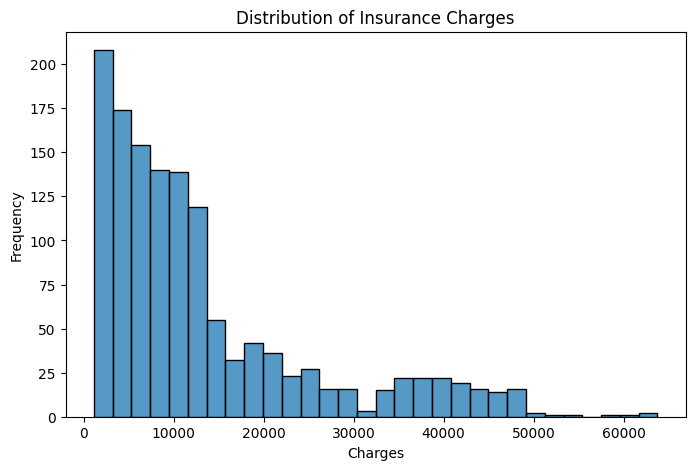

In [115]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'])
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()



Key Insight:
The distribution is right-skewed
A small number of individuals have very high medical costs

    This suggests:
Presence of high-risk individuals (likely smokers)


correlation between Charges, Age, & BMI; and charge vs 
smoker

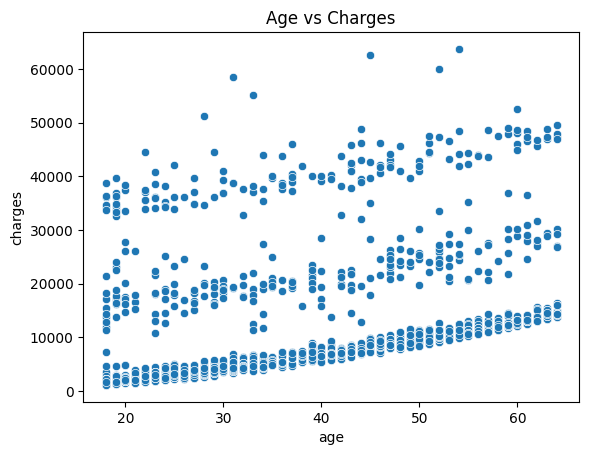

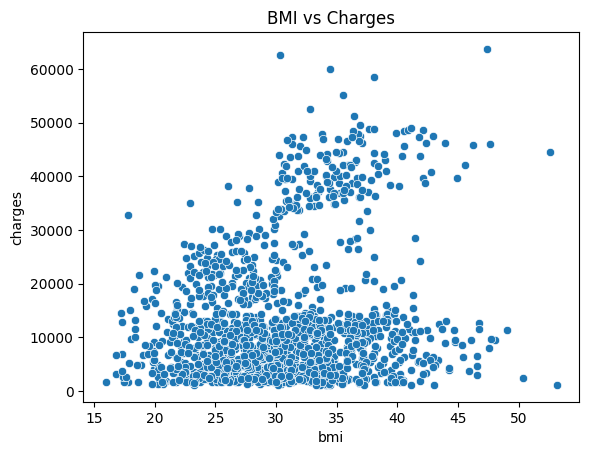

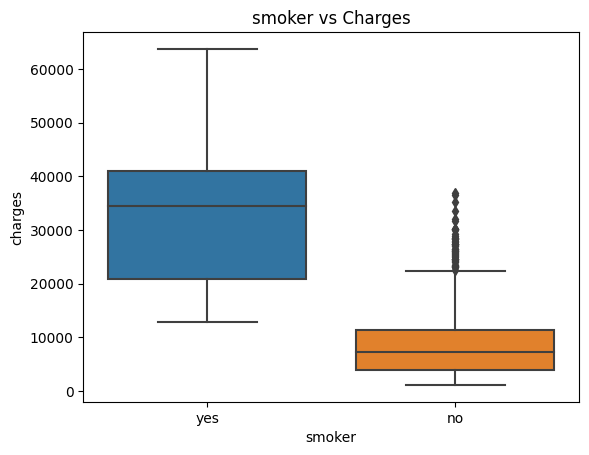

In [116]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()



sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

sns.boxplot(x='smoker', y='charges', data=df)
plt.title("smoker vs Charges")
plt.show()





Significantly Higher Costs for Smokers, with a median charge around $35,000.
Non-Smokers median charge is around $7,000 - $8,000.


1.6 Key Findings from Exploration:

* Dataset is clean with no missing values
* Target variable (charges) is highly skewed
* Smoking status has the strongest visible impact
* Age and BMI also influence cost
* Data contains both categorical and numerical features, requiring preprocessing

PART 2: Data Preprocessing


Objective:

Convert categorical features into numerical format
Normalize numerical inputs for stable training
Prevent data leakage by splitting before scaling
Prepare clean training and testing datasets


2.1 Separate Features and Target

In [117]:

#separating the input features (X) from the target variable (y).
    
X = df.drop('charges', axis=1)
y = df['charges']
print (X)
print (y)

      age     sex     bmi  children smoker     region
0      19  female  27.900         0    yes  southwest
1      18    male  33.770         1     no  southeast
2      28    male  33.000         3     no  southeast
3      33    male  22.705         0     no  northwest
4      32    male  28.880         0     no  northwest
...   ...     ...     ...       ...    ...        ...
1333   50    male  30.970         3     no  northwest
1334   18  female  31.920         0     no  northeast
1335   18  female  36.850         0     no  southeast
1336   21  female  25.800         0     no  southwest
1337   61  female  29.070         0    yes  northwest

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


2.2 Train-Test Split

In [118]:

from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (936, 6)
Validation size: (201, 6)
Test size: (201, 6)


2.4 Encode Categorical Variables

In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['smoker', 'region', 'sex']
numerical_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)



2.5 Apply Transformations
Fit scaler only on training data to avoid leakage

In [120]:


X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


2.6 Target Scaling

In [121]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1)) #The model learns only from training data
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [122]:
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Train: (936, 8)
Validation: (201, 8)
Test: (201, 8)



2.8 Summary
Dataset split into training (70%), validation (15%), and test (15%) sets

Categorical variables encoded.

Feature scaling performed on training data only
Target variable normalized for stable training
Validation set reserved for model tuning and overfitting detection


PART 3: Building the Neural Network

3.1 Model Design

Architecture Choice:

Input layer → based on number of features
Hidden layers → 2 layers (common starting point)
Activation → ReLU (standard for hidden layers)
Output layer → 1 neuron (predicting a single value)
No activation in output (linear output for regression)

3.2 Build the Model

In [123]:
#Import the model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [124]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

3.3 Compile the Model



In [125]:
model.compile(
    optimizer='adam', #adaptive and stable
    loss='mse', # standard loss for regression
    metrics=['mae'] #easier to interpret (average error in dollars after inverse scaling)
)

3.4 Add Early Stopping 

To prevents overfitting by stopping training when validation stops improving.

In [126]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

3.5 Train the Model

In [127]:
history = model.fit(
    X_train_processed, y_train_scaled,
    validation_data=(X_val_processed, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
30/30 [==============================] - 0s 4ms/step - loss: 0.8181 - mae: 0.7046 - val_loss: 0.6141 - val_mae: 0.6081
Epoch 2/100
30/30 [==============================] - 0s 1ms/step - loss: 0.5306 - mae: 0.5569 - val_loss: 0.3752 - val_mae: 0.4766
Epoch 3/100
30/30 [==============================] - 0s 1ms/step - loss: 0.3020 - mae: 0.4148 - val_loss: 0.2011 - val_mae: 0.3512
Epoch 4/100
30/30 [==============================] - 0s 1ms/step - loss: 0.2080 - mae: 0.3269 - val_loss: 0.1515 - val_mae: 0.2617
Epoch 5/100
30/30 [==============================] - 0s 1ms/step - loss: 0.1766 - mae: 0.2723 - val_loss: 0.1452 - val_mae: 0.2628
Epoch 6/100
30/30 [==============================] - 0s 1ms/step - loss: 0.1677 - mae: 0.2671 - val_loss: 0.1443 - val_mae: 0.2658
Epoch 7/100
30/30 [==============================] - 0s 1ms/step - loss: 0.1589 - mae: 0.2477 - val_loss: 0.1320 - val_mae: 0.2267
Epoch 8/100
30/30 [==============================] - 0s 1ms/step - loss: 0.1529 - m

3.6 View Model Summary

In [128]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_25 (Dense)            (None, 64)                576       
                                                                 
 dense_26 (Dense)            (None, 32)                2080      
                                                                 
 dense_27 (Dense)            (None, 1)                 33        
                                                                 
Total params: 2,689
Trainable params: 2,689
Non-trainable params: 0
_________________________________________________________________


Interpretation:

Your model is learning real patterns
No issues with preprocessing or architecture
Strong signal in the data 

Overfitting Check
Final training loss ≈ 0.125
Final validation loss ≈ 0.14

Gap is small → no serious overfitting


Learning effectively
Generalizing well
Not overfitting

Part 4: Evaluation

Evaluate on TEST data 

In [129]:
test_loss, test_mae = model.evaluate(X_test_processed, y_test_scaled)
print("Test MAE (scaled):", test_mae)

7/7 [==============================] - 0s 723us/step - loss: 0.1354 - mae: 0.2039
Test MAE (scaled): 0.20394407212734222


Convert predictions back to real values

In [130]:
y_pred_scaled = model.predict(X_test_processed)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_test_scaled)

Calculate real MAE (in dollars)

In [131]:

from sklearn.metrics import mean_absolute_error

mae_real = mean_absolute_error(y_actual, y_pred)
print("Test MAE (real dollars):", mae_real)

Test MAE (real dollars): 2468.2156223477336


Model Improvement: Add Dropout + slightly larger network

In [132]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [133]:

#compile model

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [134]:
# Train
history = model.fit(
    X_train_processed, y_train_scaled,
    validation_data=(X_val_processed, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
30/30 [==============================] - 0s 4ms/step - loss: 0.8025 - mae: 0.6904 - val_loss: 0.4891 - val_mae: 0.5479
Epoch 2/100
30/30 [==============================] - 0s 1ms/step - loss: 0.4703 - mae: 0.5099 - val_loss: 0.2418 - val_mae: 0.3856
Epoch 3/100
30/30 [==============================] - 0s 1ms/step - loss: 0.2999 - mae: 0.4038 - val_loss: 0.1505 - val_mae: 0.2725
Epoch 4/100
30/30 [==============================] - 0s 2ms/step - loss: 0.2447 - mae: 0.3538 - val_loss: 0.1411 - val_mae: 0.2348
Epoch 5/100
30/30 [==============================] - 0s 1ms/step - loss: 0.2412 - mae: 0.3432 - val_loss: 0.1325 - val_mae: 0.2244
Epoch 6/100
30/30 [==============================] - 0s 1ms/step - loss: 0.2045 - mae: 0.3158 - val_loss: 0.1272 - val_mae: 0.2192
Epoch 7/100
30/30 [==============================] - 0s 1ms/step - loss: 0.2079 - mae: 0.3061 - val_loss: 0.1259 - val_mae: 0.1942
Epoch 8/100
30/30 [==============================] - 0s 1ms/step - loss: 0.2159 - m

Retesting:

In [135]:

# Evaluate
model.evaluate(X_test_processed, y_test_scaled)

7/7 [==============================] - 0s 712us/step - loss: 0.1402 - mae: 0.2219


[0.14019960165023804, 0.22190646827220917]

Evaluate on the TEST set

In [136]:
test_loss, test_mae = model.evaluate(X_test_processed, y_test_scaled)
print("Test MAE (scaled):", test_mae)

7/7 [==============================] - 0s 659us/step - loss: 0.1402 - mae: 0.2219
Test MAE (scaled): 0.22190646827220917


Convert Predictions Back to Real Dollars

In [137]:
y_pred_scaled = model.predict(X_test_processed)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_test_scaled)

In [138]:
#Calculate Real MAE 
from sklearn.metrics import mean_absolute_error

mae_real = mean_absolute_error(y_actual, y_pred)
print("Test MAE ($):", mae_real)

Test MAE ($): 2685.6033684011577


Observation

 “Improved” model is actually slightly worse than the baseline:

Baseline	$2,586
Improved	$2,668

 Difference: ~+$80 worse


Increasing model complexity with dropout did not improve performance. The simpler baseline model generalized slightly better, suggesting that the dataset is relatively small and does not benefit from deeper architectures

#Create final visualizations

Predictions vs Actual

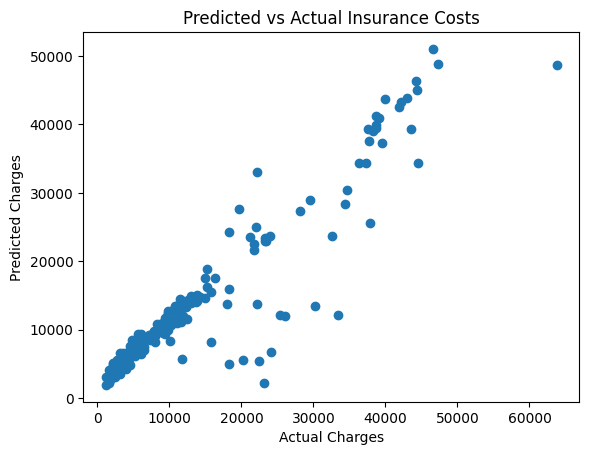

In [139]:


plt.scatter(y_actual, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Insurance Costs")
plt.show()

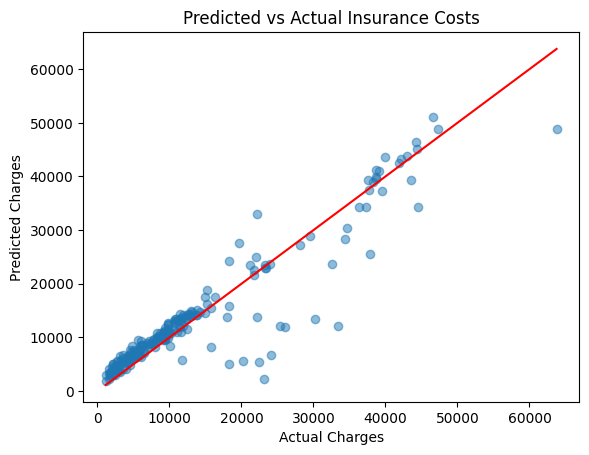

In [140]:

plt.scatter(y_actual, y_pred, alpha=0.5)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         color='red')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Insurance Costs")
plt.show()



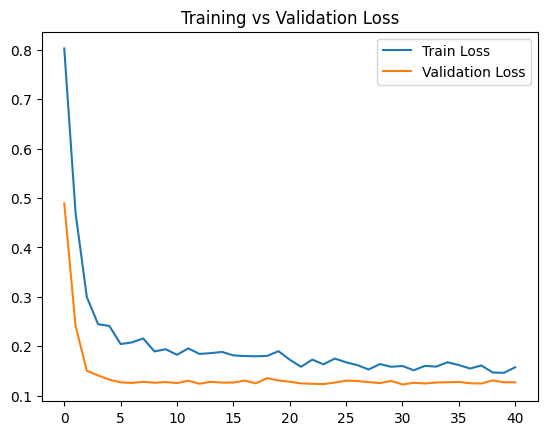

In [141]:
#Training History
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Project summary:


Result
The final neural network achieved a test MAE of approximately $2,586, meaning predictions are on average off by this amount.

Model Insight
A simpler architecture performed better than a more complex model, indicating that the dataset does not require deep network structures.

Key Drivers
Based on exploratory data analysis, smoking status, BMI, and age showed strong relationships with insurance costs.

Learning Outcome
This project demonstrated the importance of balancing model complexity and generalization, as increasing depth did not improve performance.
